# Notebook 2: Skill Extraction Agents
## Agent 1 (Resume) & Agent 2 (Job Description)

This notebook implements:
1. **Phrase-based skill extraction** using our curated skill dictionary
2. **Multi-word pattern matching** with normalization to canonical skill names
3. **Agent 1**: Extract skills from resumes
4. **Agent 2**: Extract skills from job descriptions (same pipeline, ensures alignment)
5. **Extraction quality analysis** and validation


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# # ============================================================
# # Setup
# # ============================================================
# import os
# import re
# import json
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import spacy
# from collections import Counter, defaultdict
# import warnings
# warnings.filterwarnings('ignore')

# nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

# # Load preprocessed data
# df_jobs = pd.read_csv('data/processed/jobs_filtered.csv')
# df_resumes = pd.read_csv('data/processed/resumes_filtered.csv')

# with open('data/processed/skill_dictionary.json') as f:
#     SKILL_DICTIONARY = json.load(f)
# with open('data/processed/skill_lookup.json') as f:
#     skill_lookup = json.load(f)
# with open('data/processed/skill_category_map.json') as f:
#     skill_category_map = json.load(f)
# with open('data/processed/column_config.json') as f:
#     col_config = json.load(f)

# title_col = col_config['jobs_title_col']
# desc_col = col_config['jobs_desc_col']
# text_col = col_config['resume_text_col']
# cat_col = col_config['resume_cat_col']

# print(f"Loaded {len(df_jobs)} jobs, {len(df_resumes)} resumes")
# print(f"Skill dictionary: {len(skill_lookup)} aliases -> {len(skill_category_map)} canonical skills")


In [2]:
# ============================================================
# Setup & Drive Mount
# ============================================================
import os
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from collections import Counter, defaultdict
from google.colab import drive  # Added for Drive access
import warnings
warnings.filterwarnings('ignore')

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the project base path (based on your Drive screenshot)
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/DM_project_1'
DATA_PATH = os.path.join(BASE_PATH, 'data/processed')

nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

# 3. Load preprocessed data using the new paths
df_jobs = pd.read_csv(os.path.join(DATA_PATH, 'jobs_filtered.csv'))
df_resumes = pd.read_csv(os.path.join(DATA_PATH, 'resumes_filtered.csv'))

with open(os.path.join(DATA_PATH, 'skill_dictionary.json')) as f:
    SKILL_DICTIONARY = json.load(f)
with open(os.path.join(DATA_PATH, 'skill_lookup.json')) as f:
    skill_lookup = json.load(f)
with open(os.path.join(DATA_PATH, 'skill_category_map.json')) as f:
    skill_category_map = json.load(f)
with open(os.path.join(DATA_PATH, 'column_config.json')) as f:
    col_config = json.load(f)

# The rest of your configuration remains the same
title_col = col_config['jobs_title_col']
desc_col = col_config['jobs_desc_col']
text_col = col_config['resume_text_col']
cat_col = col_config['resume_cat_col']

print(f"Loaded {len(df_jobs)} jobs, {len(df_resumes)} resumes")
print(f"Skill dictionary: {len(skill_lookup)} aliases -> {len(skill_category_map)} canonical skills")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 813 jobs, 106 resumes
Skill dictionary: 332 aliases -> 121 canonical skills


## 1. Skill Extraction Engine

The extraction pipeline uses a multi-pass approach:
1. **Exact multi-word matching**: Check for multi-word skill phrases first (e.g., "machine learning", "data visualization")
2. **Single-word matching**: Then check remaining tokens for single-word skill matches
3. **Normalization**: Map all matches to canonical skill names via the skill dictionary

This phrase-level approach is motivated by Bekkerman & Gavish (2011), who showed that phrase-based semantic units capture meaning more effectively than raw keywords.


In [3]:
# ============================================================
# 1. Skill Extraction Engine (Shared by Agent 1 & Agent 2)
# ============================================================

class SkillExtractor:
    """
    Phrase-based skill extractor using curated dictionary matching.
    Supports multi-word phrases and maps to canonical skill names.
    """

    def __init__(self, skill_lookup, skill_category_map):
        self.skill_lookup = skill_lookup
        self.skill_category_map = skill_category_map

        # Sort aliases by length (longest first) for greedy matching
        self.sorted_aliases = sorted(skill_lookup.keys(), key=len, reverse=True)

        # Pre-compile regex patterns for multi-word skills
        self.patterns = []
        for alias in self.sorted_aliases:
            # Word boundary matching for each alias
            pattern = re.compile(r'\b' + re.escape(alias) + r'\b', re.IGNORECASE)
            self.patterns.append((pattern, alias))

    def extract_skills(self, text):
        """
        Extract skills from text using greedy phrase matching.

        Returns:
            dict with:
                - 'skills': list of canonical skill names (unique)
                - 'skill_counts': dict of canonical_skill -> count
                - 'skill_categories': dict of canonical_skill -> category
                - 'matched_phrases': list of (original_phrase, canonical_skill) tuples
        """
        if not isinstance(text, str) or len(text) < 5:
            return {
                'skills': [],
                'skill_counts': {},
                'skill_categories': {},
                'matched_phrases': []
            }

        text_lower = text.lower()
        found_skills = Counter()
        matched_phrases = []
        # Track matched character positions to avoid double-counting
        matched_positions = set()

        for pattern, alias in self.patterns:
            for match in pattern.finditer(text_lower):
                start, end = match.start(), match.end()
                # Check if this region is already matched by a longer phrase
                if any(pos in matched_positions for pos in range(start, end)):
                    continue
                canonical = self.skill_lookup[alias]
                found_skills[canonical] += 1
                matched_phrases.append((match.group(), canonical))
                matched_positions.update(range(start, end))

        skills_list = list(found_skills.keys())
        categories = {s: self.skill_category_map.get(s, 'unknown') for s in skills_list}

        return {
            'skills': skills_list,
            'skill_counts': dict(found_skills),
            'skill_categories': categories,
            'matched_phrases': matched_phrases,
        }

    def extract_skills_simple(self, text):
        """Return just the list of canonical skill names."""
        return self.extract_skills(text)['skills']


# Initialize the extractor
extractor = SkillExtractor(skill_lookup, skill_category_map)

# Quick test
test_text = "Experienced data scientist with Python, machine learning, TensorFlow, and SQL skills. Built deep learning models using PyTorch and deployed on AWS with Docker."
result = extractor.extract_skills(test_text)
print("Test extraction:")
print(f"  Input: {test_text[:80]}...")
print(f"  Skills found: {result['skills']}")
print(f"  Categories: {result['skill_categories']}")
print(f"  Matched phrases: {result['matched_phrases']}")


Test extraction:
  Input: Experienced data scientist with Python, machine learning, TensorFlow, and SQL sk...
  Skills found: ['machine learning', 'deep learning', 'tensorflow', 'pytorch', 'python', 'docker', 'sql', 'aws']
  Categories: {'machine learning': 'machine_learning', 'deep learning': 'machine_learning', 'tensorflow': 'ml_frameworks', 'pytorch': 'ml_frameworks', 'python': 'programming_languages', 'docker': 'cloud_devops', 'sql': 'programming_languages', 'aws': 'cloud_devops'}
  Matched phrases: [('machine learning', 'machine learning'), ('deep learning', 'deep learning'), ('tensorflow', 'tensorflow'), ('pytorch', 'pytorch'), ('python', 'python'), ('docker', 'docker'), ('sql', 'sql'), ('aws', 'aws')]


## 2. Agent 1: Resume Skill Extraction

Applies the extraction engine to all resumes in our filtered dataset.


In [4]:
# ============================================================
# 2. Agent 1: Resume Skill Extraction
# ============================================================

print("Agent 1: Extracting skills from resumes...")

# Use the clean_resume column (preprocessed text) for better matching
# But also extract from original text to catch proper nouns like TensorFlow
resume_extractions = []
for idx, row in df_resumes.iterrows():
    # Extract from both original and cleaned text, merge results
    original_text = str(row.get(text_col, ''))
    cleaned_text = str(row.get('clean_resume', ''))

    result_orig = extractor.extract_skills(original_text)
    result_clean = extractor.extract_skills(cleaned_text)

    # Merge: union of skills from both passes
    all_skills = list(set(result_orig['skills']) | set(result_clean['skills']))
    all_counts = {**result_clean['skill_counts'], **result_orig['skill_counts']}
    all_categories = {s: skill_category_map.get(s, 'unknown') for s in all_skills}

    resume_extractions.append({
        'index': idx,
        'category': row.get(cat_col, 'unknown'),
        'skills': all_skills,
        'skill_counts': all_counts,
        'skill_categories': all_categories,
        'num_skills': len(all_skills),
    })

df_resume_skills = pd.DataFrame(resume_extractions)

# Add skills as a column to the main dataframe
df_resumes['extracted_skills'] = df_resume_skills['skills'].apply(json.dumps)
df_resumes['num_skills'] = df_resume_skills['num_skills']

print(f"\n✅ Agent 1 complete!")
print(f"  Resumes processed: {len(df_resumes)}")
print(f"  Avg skills per resume: {df_resume_skills['num_skills'].mean():.1f}")
print(f"  Median skills per resume: {df_resume_skills['num_skills'].median():.0f}")
print(f"  Resumes with 0 skills: {(df_resume_skills['num_skills'] == 0).sum()}")

# Top skills across all resumes
all_resume_skills = []
for skills in df_resume_skills['skills']:
    all_resume_skills.extend(skills)
resume_skill_freq = Counter(all_resume_skills)
print(f"\nTop 20 skills across all resumes:")
for skill, count in resume_skill_freq.most_common(20):
    print(f"  {skill}: {count} ({100*count/len(df_resumes):.1f}% of resumes)")


Agent 1: Extracting skills from resumes...

✅ Agent 1 complete!
  Resumes processed: 106
  Avg skills per resume: 7.4
  Median skills per resume: 7
  Resumes with 0 skills: 1

Top 20 skills across all resumes:
  sql: 48 (45.3% of resumes)
  java: 42 (39.6% of resumes)
  html: 36 (34.0% of resumes)
  linux: 34 (32.1% of resumes)
  oracle: 33 (31.1% of resumes)
  mysql: 30 (28.3% of resumes)
  python: 29 (27.4% of resumes)
  javascript: 26 (24.5% of resumes)
  communication: 26 (24.5% of resumes)
  css: 22 (20.8% of resumes)
  sql server: 21 (19.8% of resumes)
  project management: 18 (17.0% of resumes)
  supervised learning: 16 (15.1% of resumes)
  rest api: 15 (14.2% of resumes)
  machine learning: 14 (13.2% of resumes)
  git: 14 (13.2% of resumes)
  excel: 14 (13.2% of resumes)
  angular: 12 (11.3% of resumes)
  research: 11 (10.4% of resumes)
  aws: 11 (10.4% of resumes)


## 3. Agent 2: Job Requirement Extraction

Same extraction pipeline applied to job descriptions, ensuring vocabulary alignment with Agent 1.


In [5]:
# ============================================================
# 3. Agent 2: Job Requirement Extraction
# ============================================================

print("Agent 2: Extracting skills from job descriptions...")

job_extractions = []
for idx, row in df_jobs.iterrows():
    original_text = str(row.get(desc_col, ''))
    cleaned_text = str(row.get('clean_description', ''))

    result_orig = extractor.extract_skills(original_text)
    result_clean = extractor.extract_skills(cleaned_text)

    all_skills = list(set(result_orig['skills']) | set(result_clean['skills']))
    all_counts = {**result_clean['skill_counts'], **result_orig['skill_counts']}
    all_categories = {s: skill_category_map.get(s, 'unknown') for s in all_skills}

    job_extractions.append({
        'index': idx,
        'job_title': row.get(title_col, 'unknown'),
        'skills': all_skills,
        'skill_counts': all_counts,
        'skill_categories': all_categories,
        'num_skills': len(all_skills),
    })

df_job_skills = pd.DataFrame(job_extractions)

df_jobs['extracted_skills'] = df_job_skills['skills'].apply(json.dumps)
df_jobs['num_skills'] = df_job_skills['num_skills']

print(f"\n✅ Agent 2 complete!")
print(f"  Jobs processed: {len(df_jobs)}")
print(f"  Avg skills per job: {df_job_skills['num_skills'].mean():.1f}")
print(f"  Median skills per job: {df_job_skills['num_skills'].median():.0f}")
print(f"  Jobs with 0 skills: {(df_job_skills['num_skills'] == 0).sum()}")

all_job_skills = []
for skills in df_job_skills['skills']:
    all_job_skills.extend(skills)
job_skill_freq = Counter(all_job_skills)
print(f"\nTop 20 skills across all job postings:")
for skill, count in job_skill_freq.most_common(20):
    print(f"  {skill}: {count} ({100*count/len(df_jobs):.1f}% of jobs)")


Agent 2: Extracting skills from job descriptions...

✅ Agent 2 complete!
  Jobs processed: 813
  Avg skills per job: 10.7
  Median skills per job: 10
  Jobs with 0 skills: 3

Top 20 skills across all job postings:
  sql: 566 (69.6% of jobs)
  python: 558 (68.6% of jobs)
  data analysis: 460 (56.6% of jobs)
  communication: 448 (55.1% of jobs)
  teamwork: 392 (48.2% of jobs)
  etl: 309 (38.0% of jobs)
  machine learning: 308 (37.9% of jobs)
  statistical analysis: 283 (34.8% of jobs)
  tableau: 225 (27.7% of jobs)
  data visualization: 224 (27.6% of jobs)
  problem solving: 218 (26.8% of jobs)
  power bi: 213 (26.2% of jobs)
  aws: 202 (24.8% of jobs)
  data governance: 200 (24.6% of jobs)
  research: 194 (23.9% of jobs)
  apache spark: 192 (23.6% of jobs)
  project management: 184 (22.6% of jobs)
  leadership: 173 (21.3% of jobs)
  excel: 167 (20.5% of jobs)
  business acumen: 165 (20.3% of jobs)


## 4. Extraction Quality Analysis


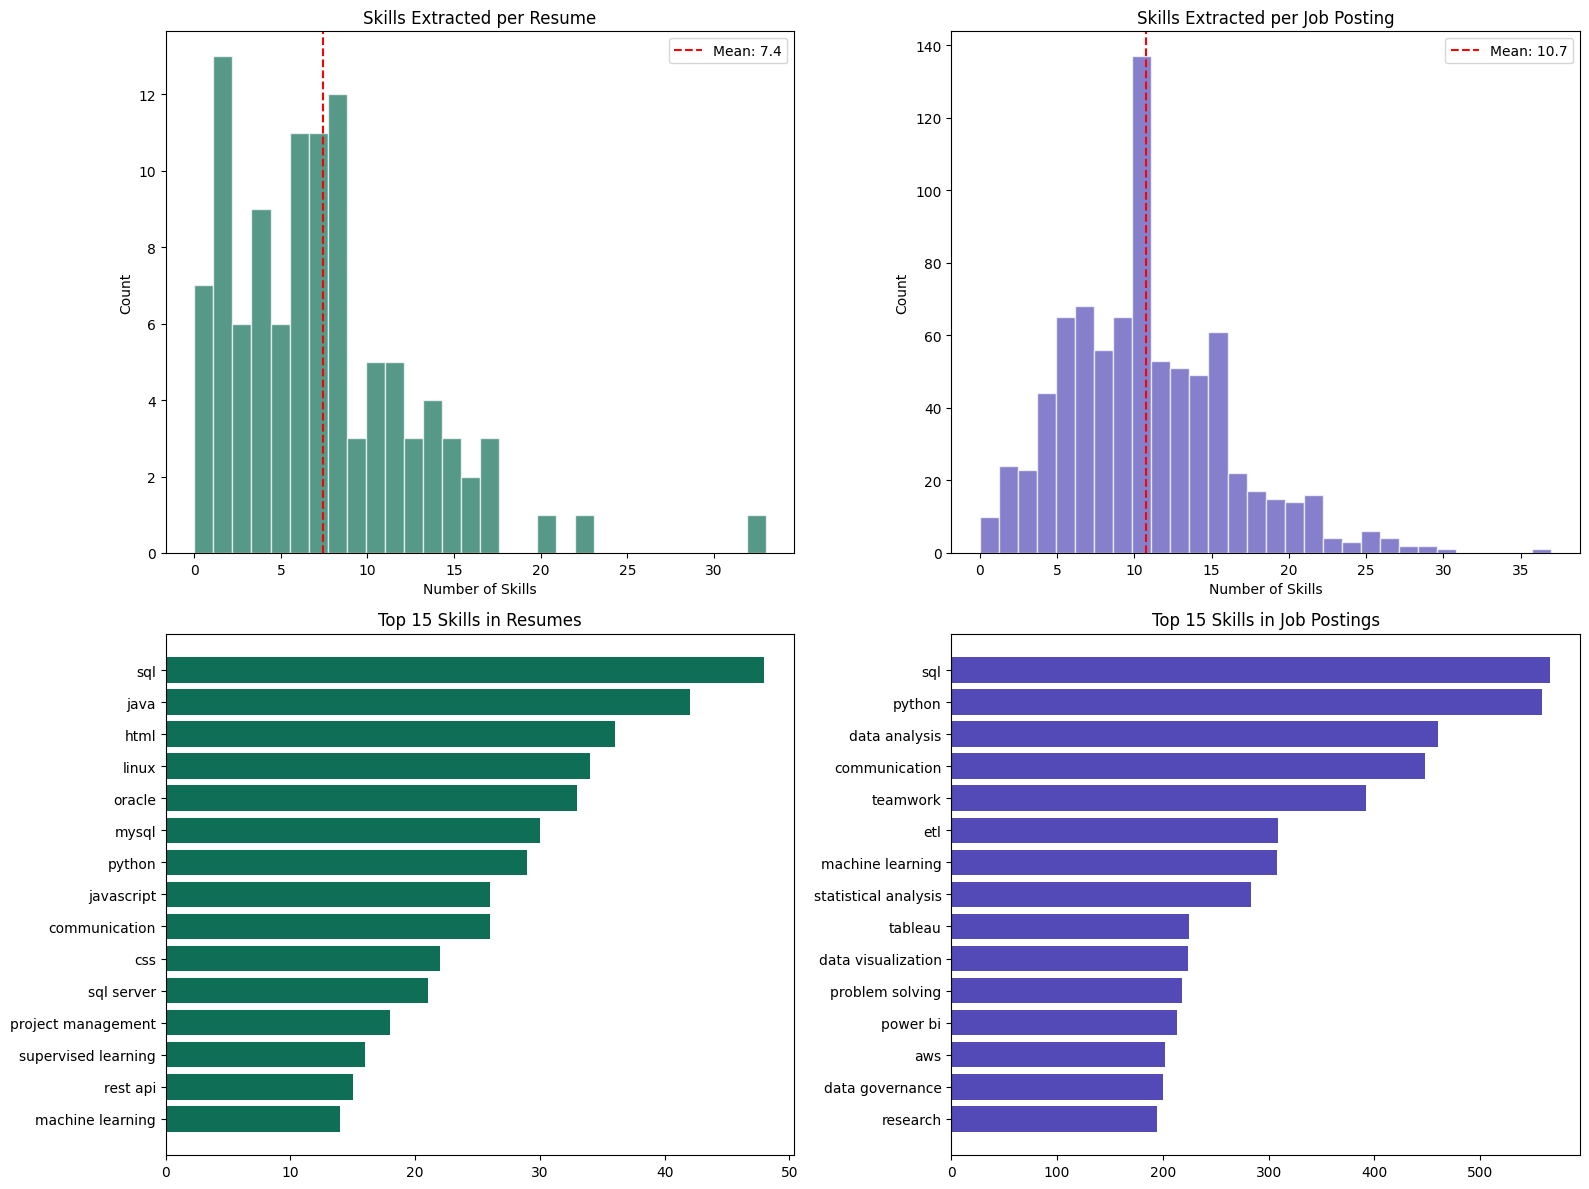

Analysis successfully saved to Drive: /content/drive/MyDrive/Colab Notebooks/DM_project_1/outputs/02_skill_extraction_analysis.png


In [6]:
# ============================================================
# 4. Extraction Analysis & Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 4a. Skills per resume distribution
axes[0, 0].hist(df_resume_skills['num_skills'], bins=30, color='#0F6E56', alpha=0.7, edgecolor='white')
axes[0, 0].set_title('Skills Extracted per Resume')
axes[0, 0].set_xlabel('Number of Skills')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(df_resume_skills['num_skills'].mean(), color='red', linestyle='--',
                   label=f"Mean: {df_resume_skills['num_skills'].mean():.1f}")
axes[0, 0].legend()

# 4b. Skills per job distribution
axes[0, 1].hist(df_job_skills['num_skills'], bins=30, color='#534AB7', alpha=0.7, edgecolor='white')
axes[0, 1].set_title('Skills Extracted per Job Posting')
axes[0, 1].set_xlabel('Number of Skills')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(df_job_skills['num_skills'].mean(), color='red', linestyle='--',
                   label=f"Mean: {df_job_skills['num_skills'].mean():.1f}")
axes[0, 1].legend()

# 4c. Top 15 resume skills
top_resume = resume_skill_freq.most_common(15)
axes[1, 0].barh([s[0] for s in top_resume], [s[1] for s in top_resume], color='#0F6E56')
axes[1, 0].set_title('Top 15 Skills in Resumes')
axes[1, 0].invert_yaxis()

# 4d. Top 15 job skills
top_jobs = job_skill_freq.most_common(15)
axes[1, 1].barh([s[0] for s in top_jobs], [s[1] for s in top_jobs], color='#534AB7')
axes[1, 1].set_title('Top 15 Skills in Job Postings')
axes[1, 1].invert_yaxis()

OUTPUT_PATH = os.path.join(BASE_PATH, 'outputs')
os.makedirs(OUTPUT_PATH, exist_ok=True)
save_file_path = os.path.join(OUTPUT_PATH, '02_skill_extraction_analysis.png')
plt.tight_layout()
plt.savefig(save_file_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Analysis successfully saved to Drive: {save_file_path}")


# plt.savefig('outputs/02_skill_extraction_analysis.png', dpi=150, bbox_inches='tight')



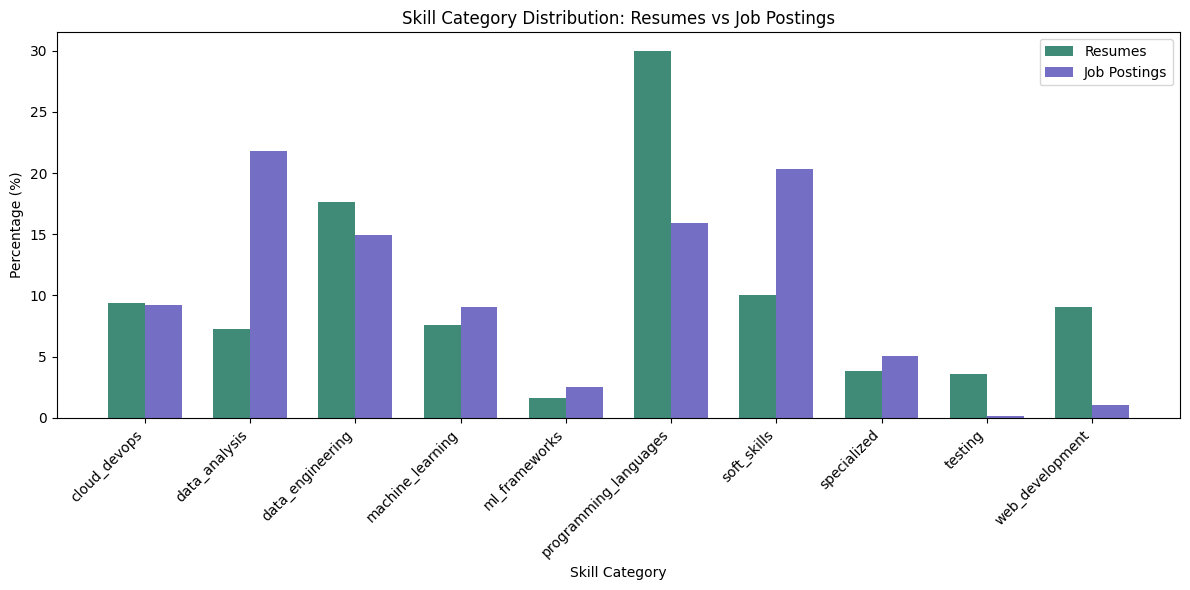

In [7]:
# ============================================================
# 4b. Skill Category Distribution Comparison
# ============================================================

def get_category_distribution(skill_list, category_map):
    cat_counts = Counter()
    for skills in skill_list:
        for skill in skills:
            cat = category_map.get(skill, 'unknown')
            cat_counts[cat] += 1
    return cat_counts

resume_cats = get_category_distribution(df_resume_skills['skills'], skill_category_map)
job_cats = get_category_distribution(df_job_skills['skills'], skill_category_map)

all_categories = sorted(set(list(resume_cats.keys()) + list(job_cats.keys())))
resume_vals = [resume_cats.get(c, 0) for c in all_categories]
job_vals = [job_cats.get(c, 0) for c in all_categories]

# Normalize to percentages
resume_pcts = [100 * v / sum(resume_vals) for v in resume_vals]
job_pcts = [100 * v / sum(job_vals) for v in job_vals]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_categories))
width = 0.35
ax.bar(x - width/2, resume_pcts, width, label='Resumes', color='#0F6E56', alpha=0.8)
ax.bar(x + width/2, job_pcts, width, label='Job Postings', color='#534AB7', alpha=0.8)
ax.set_xlabel('Skill Category')
ax.set_ylabel('Percentage (%)')
ax.set_title('Skill Category Distribution: Resumes vs Job Postings')
ax.set_xticks(x)
ax.set_xticklabels(all_categories, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
save_file_path = os.path.join(OUTPUT_PATH, '02_category_comparison.png')
# plt.savefig('outputs/02_category_comparison.png', dpi=150, bbox_inches='tight')
plt.savefig(save_file_path, dpi=150, bbox_inches='tight')
plt.show()


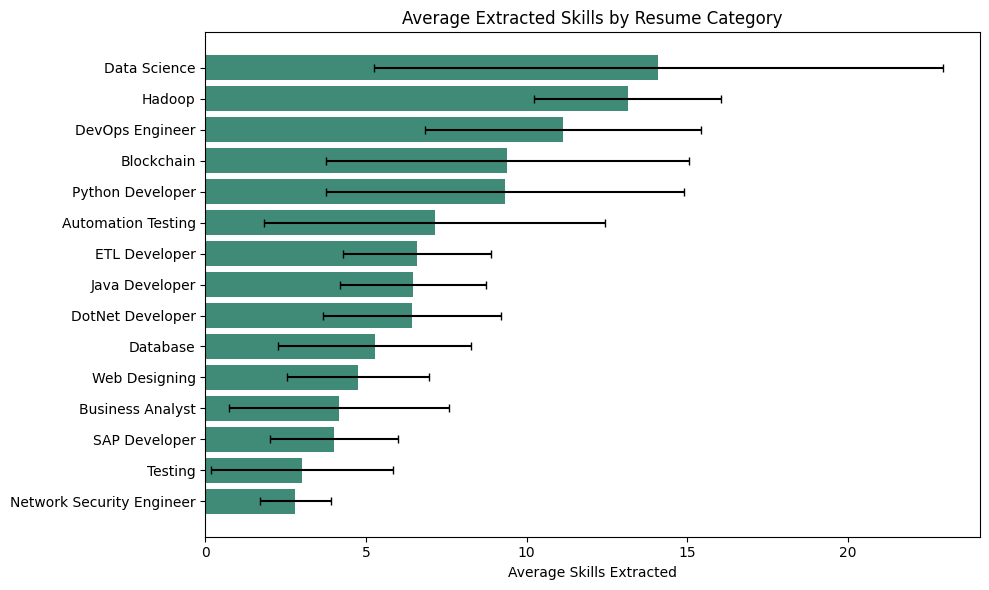

In [8]:
# ============================================================
# 4c. Average Skills by Resume Category
# ============================================================

cat_skill_means = df_resumes.groupby(cat_col)['num_skills'].agg(['mean', 'std', 'count'])
cat_skill_means = cat_skill_means.sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cat_skill_means.index, cat_skill_means['mean'], color='#0F6E56', alpha=0.8)
ax.errorbar(cat_skill_means['mean'], cat_skill_means.index,
            xerr=cat_skill_means['std'], fmt='none', color='black', capsize=3)
ax.set_xlabel('Average Skills Extracted')
ax.set_title('Average Extracted Skills by Resume Category')
plt.tight_layout()
plt.savefig(save_file_path, dpi=150, bbox_inches='tight')
save_file_path = os.path.join(OUTPUT_PATH, '02_skills_by_category.png')
# plt.savefig('outputs/02_skills_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# # ============================================================
# # 5. Save Extraction Results
# # ============================================================

# # Save enriched dataframes
# df_jobs.to_csv('data/processed/jobs_with_skills.csv', index=False)
# df_resumes.to_csv('data/processed/resumes_with_skills.csv', index=False)

# # Save skill frequency data for downstream use
# import pickle

# extraction_data = {
#     'resume_skill_freq': dict(resume_skill_freq),
#     'job_skill_freq': dict(job_skill_freq),
#     'resume_extractions': resume_extractions,
#     'job_extractions': job_extractions,
# }
# with open('data/processed/extraction_results.pkl', 'wb') as f:
#     pickle.dump(extraction_data, f)

# print("✅ Extraction results saved!")
# print(f"  data/processed/jobs_with_skills.csv")
# print(f"  data/processed/resumes_with_skills.csv")
# print(f"  data/processed/extraction_results.pkl")
# print(f"\n{'='*60}")
# print("PHASE 2a COMPLETE — Ready for Notebook 03: Embeddings")
# print(f"{'='*60}")


In [9]:
# ============================================================
# 5. Save Extraction Results (TO GOOGLE DRIVE)
# ============================================================
import pickle
import os

# 1. Use the DATA_PATH we defined earlier:
# DATA_PATH = os.path.join(BASE_PATH, 'data/processed')
# Ensure the folder exists in Drive
os.makedirs(DATA_PATH, exist_ok=True)

# 2. Define the full file paths
jobs_path = os.path.join(DATA_PATH, 'jobs_with_skills.csv')
resumes_path = os.path.join(DATA_PATH, 'resumes_with_skills.csv')
pickle_path = os.path.join(DATA_PATH, 'extraction_results.pkl')

# 3. Save enriched dataframes
df_jobs.to_csv(jobs_path, index=False)
df_resumes.to_csv(resumes_path, index=False)

# 4. Save skill frequency data for downstream use
extraction_data = {
    'resume_skill_freq': dict(resume_skill_freq),
    'job_skill_freq': dict(job_skill_freq),
    'resume_extractions': resume_extractions,
    'job_extractions': job_extractions,
}

with open(pickle_path, 'wb') as f:
    pickle.dump(extraction_data, f)

print("✅ Extraction results saved to Google Drive!")
print(f"  {jobs_path}")
print(f"  {resumes_path}")
print(f"  {pickle_path}")

print(f"\n{'='*60}")
print("PHASE 2a COMPLETE — Ready for Notebook 03: Embeddings")
print(f"{'='*60}")

✅ Extraction results saved to Google Drive!
  /content/drive/MyDrive/Colab Notebooks/DM_project_1/data/processed/jobs_with_skills.csv
  /content/drive/MyDrive/Colab Notebooks/DM_project_1/data/processed/resumes_with_skills.csv
  /content/drive/MyDrive/Colab Notebooks/DM_project_1/data/processed/extraction_results.pkl

PHASE 2a COMPLETE — Ready for Notebook 03: Embeddings
